In [1]:
!pip install transformers datasets peft accelerate scikit-learn evaluate seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


# Importing Libraries

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from transformers import TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType
from transformers import TrainingArguments

# Dataset loading

In [3]:
dataset = load_dataset("cardiffnlp/tweet_eval", "emotion")

train_dataset = dataset["train"]
val_dataset = dataset["validation"]
test_dataset = dataset["test"]

label_names = train_dataset.features["label"].names
num_labels = len(label_names)

print("Number of labels:", num_labels)
print("Labels:", label_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

emotion/train-00000-of-00001.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

emotion/test-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

emotion/validation-00000-of-00001.parque(…):   0%|          | 0.00/28.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3257 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1421 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/374 [00:00<?, ? examples/s]

Number of labels: 4
Labels: ['anger', 'joy', 'optimism', 'sadness']


# Showing the Dataset

In [4]:
dataset = dataset["train"].to_pandas()

dataset.head()

,text,label
0,“Worry is a down payment on a problem you may ...,2
1,My roommate: it's okay that we can't spell bec...,0
2,No but that's so cute. Atsu was probably shy a...,1
3,Rooneys fucking untouchable isn't he? Been fuc...,0
4,it's pretty depressing when u hit pan on ur fa...,3


In [5]:
dataset.shape

(3257, 2)

# TOKENIZER

In [6]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format("torch", columns=["input_ids","attention_mask","label"])
val_dataset.set_format("torch", columns=["input_ids","attention_mask","label"])
test_dataset.set_format("torch", columns=["input_ids","attention_mask","label"])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/3257 [00:00<?, ? examples/s]

Map:   0%|          | 0/374 [00:00<?, ? examples/s]

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

In [7]:
# METRICS

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro"
    )

    acc = accuracy_score(labels, preds)

    return {"accuracy": acc, "macro_f1": f1}

# Baseline Model

In [8]:
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

trainer_baseline = Trainer(
    model=baseline_model,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("\n===== BASELINE MODEL EVALUATION =====")
trainer_baseline.evaluate()

pred = trainer_baseline.predict(test_dataset)

y_pred_multi = np.argmax(pred.predictions, axis=1)
y_true_multi = pred.label_ids
def to_binary(labels):
    return np.array([1 if l in [1,2] else 0 for l in labels])

y_true = to_binary(y_true_multi)
y_pred = to_binary(y_pred_multi)

binary_names = ["Negative", "Positive"]


print("\n===== CLASSIFICATION REPORT for BASELINE MODEL =====\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=binary_names
))


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



===== BASELINE MODEL EVALUATION =====


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



===== CLASSIFICATION REPORT for BASELINE MODEL =====

              precision    recall  f1-score   support

    Negative       0.63      0.61      0.62       940
    Positive       0.28      0.30      0.29       481

    accuracy                           0.50      1421
   macro avg       0.45      0.45      0.45      1421
weighted avg       0.51      0.50      0.51      1421



# Confusion Matrix for Baseline Model

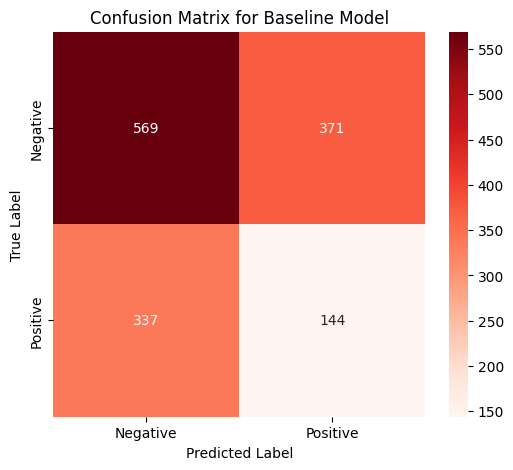

In [9]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=binary_names,
    yticklabels=binary_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Baseline Model")

plt.show()


# ROC Curve for Baseline Model

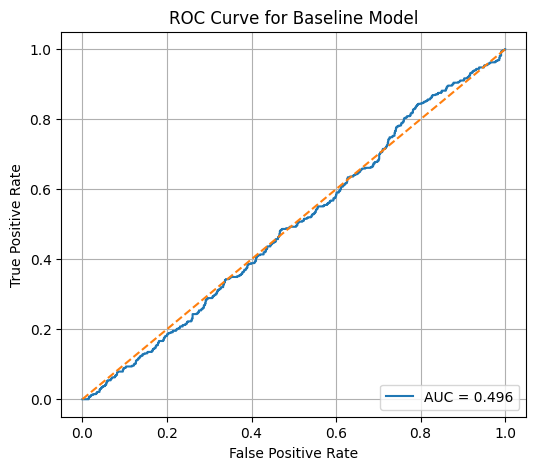

In [10]:
probs = torch.softmax(
    torch.tensor(pred.predictions), dim=1
).numpy()

# probability of positive emotions
positive_probs = probs[:,1] + probs[:,2]

fpr, tpr, _ = roc_curve(y_true, positive_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Baseline Model")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# MODEL 2: FULL FINE-TUNING (FFT)

In [11]:
fft_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

training_args_fft = TrainingArguments(
    output_dir="./fft_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=100,
    do_train=True,
    do_eval=True
)

trainer_fft = Trainer(
    model=fft_model,
    args=training_args_fft,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("\n===== TRAINING FULL FINE-TUNED MODEL =====")
trainer_fft.train()

trainer_fft.evaluate(test_dataset)

pred_fft = trainer_fft.predict(test_dataset)

y_pred_multi = np.argmax(pred_fft.predictions, axis=1)
y_true_multi = pred_fft.label_ids

def to_binary(labels):
    return np.array([1 if l in [1,2] else 0 for l in labels])

y_true = to_binary(y_true_multi)
y_pred = to_binary(y_pred_multi)

binary_names = ["Negative", "Positive"]

print("\n===== CLASSIFICATION REPORT of FULL FINE-TUNING =====\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=binary_names
))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



===== TRAINING FULL FINE-TUNED MODEL =====


Step,Training Loss
100,1.128758
200,0.796915


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


===== CLASSIFICATION REPORT of FULL FINE-TUNING =====

              precision    recall  f1-score   support

    Negative       0.86      0.95      0.90       940
    Positive       0.87      0.69      0.77       481

    accuracy                           0.86      1421
   macro avg       0.86      0.82      0.83      1421
weighted avg       0.86      0.86      0.86      1421



# Confusion Matrix for Full Fine-Tuned

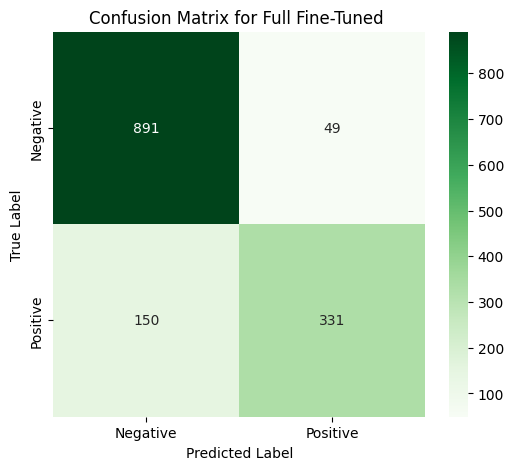

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",   # DIFFERENT COLOR
    xticklabels=binary_names,
    yticklabels=binary_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Full Fine-Tuned ")

plt.show()

# ROC Curve of Full Fine-Tuned

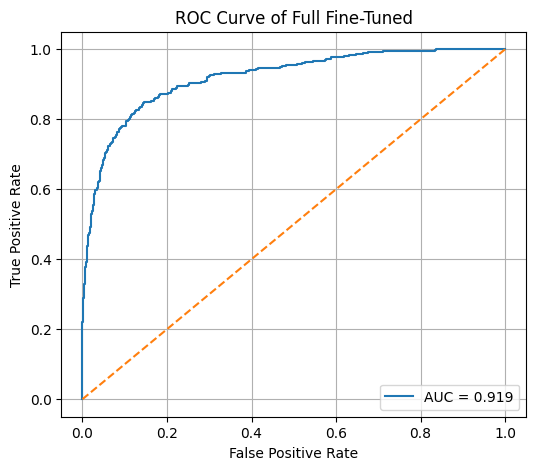

In [13]:
probs = torch.softmax(
    torch.tensor(pred_fft.predictions), dim=1
).numpy()

positive_probs = probs[:,1] + probs[:,2]

fpr, tpr, _ = roc_curve(y_true, positive_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of Full Fine-Tuned")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# MODEL 2: FULL FINE-TUNING

In [14]:
lora_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)


lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_lin", "v_lin"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)

lora_model = get_peft_model(lora_model, lora_config)

lora_model.print_trainable_parameters()


training_args_lora = TrainingArguments(
    output_dir="./lora_model",
    learning_rate=3e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    logging_steps=100,
    do_train=True,
    do_eval=True
)


trainer_lora = Trainer(
    model=lora_model,
    args=training_args_lora,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("\n===== TRAINING LoRA MODEL =====")
trainer_lora.train()


trainer_lora.evaluate(test_dataset)


pred_lora = trainer_lora.predict(test_dataset)

y_pred_multi = np.argmax(pred_lora.predictions, axis=1)
y_true_multi = pred_lora.label_ids

def to_binary(labels):
    return np.array([1 if l in [1,2] else 0 for l in labels])

y_true = to_binary(y_true_multi)
y_pred = to_binary(y_pred_multi)

binary_names = ["Negative", "Positive"]


print("\n===== CLASSIFICATION REPORT for LoRA MODEL =====\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=binary_names
))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 741,124 || all params: 67,697,672 || trainable%: 1.0948

===== TRAINING LoRA MODEL =====


Step,Training Loss
100,0.971783
200,0.674080
300,0.571855
400,0.593007



===== CLASSIFICATION REPORT for LoRA MODEL =====

              precision    recall  f1-score   support

    Negative       0.89      0.93      0.91       940
    Positive       0.85      0.78      0.81       481

    accuracy                           0.88      1421
   macro avg       0.87      0.86      0.86      1421
weighted avg       0.88      0.88      0.88      1421



# Confusion Matrix of LoRA Fine-Tuned

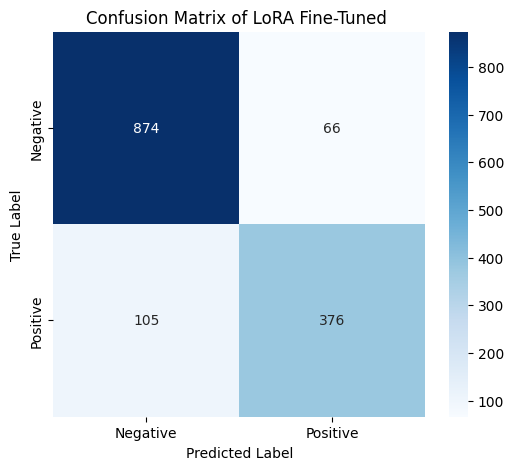

In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=binary_names,
    yticklabels=binary_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix of LoRA Fine-Tuned ")

plt.show()


# ROC Curve of LoRA Fine-Tuned

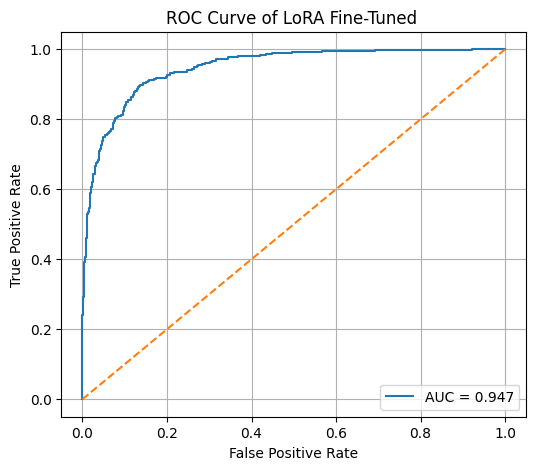

In [16]:
probs = torch.softmax(
    torch.tensor(pred_lora.predictions), dim=1
).numpy()

positive_probs = probs[:,1] + probs[:,2]

fpr, tpr, _ = roc_curve(y_true, positive_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of LoRA Fine-Tuned ")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# MODEL COMPARISON TABLE

In [17]:
def extract_metrics(trainer, dataset, model_name):

    pred = trainer.predict(dataset)

    y_pred_multi = np.argmax(pred.predictions, axis=1)
    y_true_multi = pred.label_ids

    # Binary mapping (same rule)
    def to_binary(labels):
        return np.array([1 if l in [1,2] else 0 for l in labels])

    y_true = to_binary(y_true_multi)
    y_pred = to_binary(y_pred_multi)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary"
    )

    accuracy = accuracy_score(y_true, y_pred)

    return {
        "Model": model_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4)
    }

baseline_metrics = extract_metrics(trainer_baseline, test_dataset, "Baseline")
fft_metrics = extract_metrics(trainer_fft, test_dataset, "Full Fine-Tuning")
lora_metrics = extract_metrics(trainer_lora, test_dataset, "LoRA")

comparison_df = pd.DataFrame([
    baseline_metrics,
    fft_metrics,
    lora_metrics
])

print("\n===== MODEL COMPARISON TABLE =====\n")
print(comparison_df)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



===== MODEL COMPARISON TABLE =====

              Model  Accuracy  Precision  Recall  F1 Score
0          Baseline    0.5018     0.2796  0.2994    0.2892
1  Full Fine-Tuning    0.8600     0.8711  0.6881    0.7689
2              LoRA    0.8797     0.8507  0.7817    0.8147


In [18]:
best_model = comparison_df.loc[
    comparison_df["Accuracy"].idxmax()
]

print("\n===== BEST MODEL BASED ON Accuracy =====\n")
print(best_model)


===== BEST MODEL BASED ON Accuracy =====

Model          LoRA
Accuracy     0.8797
Precision    0.8507
Recall       0.7817
F1 Score     0.8147
Name: 2, dtype: object


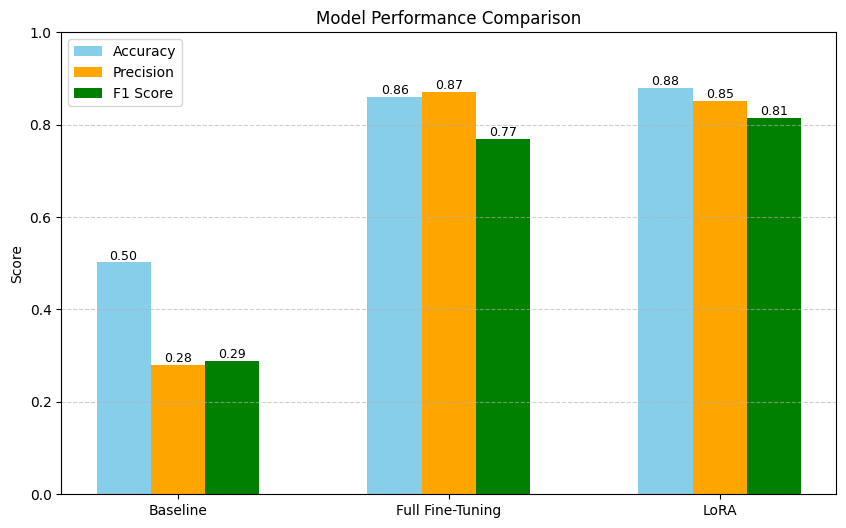

In [19]:
plt.figure(figsize=(10,6))

x = np.arange(len(comparison_df["Model"]))
width = 0.2

accuracy_vals = comparison_df["Accuracy"]
precision_vals = comparison_df["Precision"]
f1_vals = comparison_df["F1 Score"]

bars1 = plt.bar(x - width, accuracy_vals, width,
                label="Accuracy", color="skyblue")

bars2 = plt.bar(x, precision_vals, width,
                label="Precision", color="orange")

bars3 = plt.bar(x + width, f1_vals, width,
                label="F1 Score", color="green")


for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.xticks(x, comparison_df["Model"])
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.ylim(0,1)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

# ROC Curve Comparison for all the models

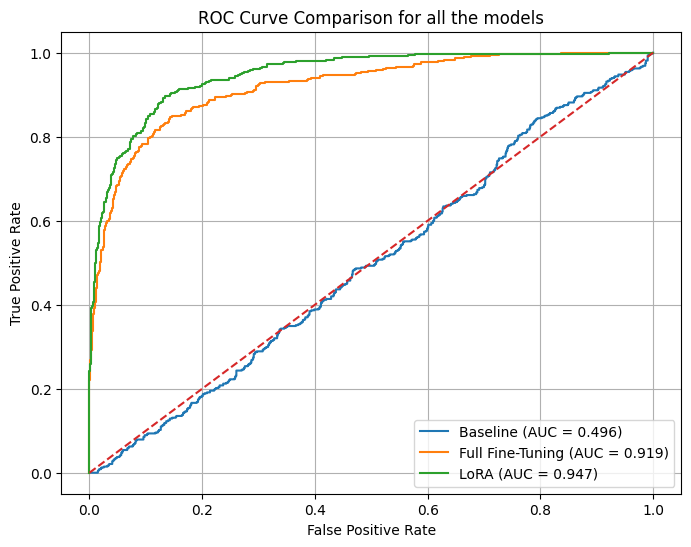

In [20]:
def get_roc_data(predictions, y_true):

    probs = torch.softmax(
        torch.tensor(predictions), dim=1
    ).numpy()

    positive_probs = probs[:, 1] + probs[:, 2]

    fpr, tpr, _ = roc_curve(y_true, positive_probs)
    roc_auc = auc(fpr, tpr)

    return fpr, tpr, roc_auc



y_true_multi = pred.label_ids

def to_binary(labels):
    return np.array([1 if l in [1,2] else 0 for l in labels])

y_true = to_binary(y_true_multi)


fpr_base, tpr_base, auc_base = get_roc_data(pred.predictions, y_true)
fpr_fft, tpr_fft, auc_fft = get_roc_data(pred_fft.predictions, y_true)
fpr_lora, tpr_lora, auc_lora = get_roc_data(pred_lora.predictions, y_true)


plt.figure(figsize=(8,6))

plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC = {auc_base:.3f})")
plt.plot(fpr_fft, tpr_fft, label=f"Full Fine-Tuning (AUC = {auc_fft:.3f})")
plt.plot(fpr_lora, tpr_lora, label=f"LoRA (AUC = {auc_lora:.3f})")


plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for all the models")

plt.legend(loc="lower right")
plt.grid(True)

plt.show()